In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from itertools import product

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

def plots_across_runs_and_feedback(feedback_values, expmnt_nums, gpt_model, memory, temperature):
    n = 2  # number of rows (positive and negative feedback)
    m = 3  # number of columns (three runs)

    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(n, m, figure=fig)
    
    max_price_pos = 0
    min_price_pos = 100
    max_price_neg = 0
    min_price_neg = 100
    
    for feedback in feedback_values:
        for expmnt_num in expmnt_nums:
            try:
                df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6.csv")
            except:
                try:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
                except:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(1)}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
            if feedback == "pos":
                max_price_pos = max(max_price_pos, df["predicted_price"].max(), df["actual_price"].max())
                min_price_pos = min(min_price_pos, df["predicted_price"].min(), df["actual_price"].min())
    
            if feedback == "neg":
                max_price_neg = max(max_price_neg, df["predicted_price"].max(), df["actual_price"].max())
                min_price_neg = min(min_price_neg, df["predicted_price"].min(), df["actual_price"].min())
    
    for i, feedback in enumerate(feedback_values):
        for j, expmnt_num in enumerate(expmnt_nums):
            ax = fig.add_subplot(gs[i, j])
            try:
                df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6.csv")
            
            except:
                try:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
                except:
                    
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(1)}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
            # Plot actual and predicted prices over time_step
            ax.plot(df['time_step'], df['actual_price'], label='Actual Price', color="black", linewidth=3)
            for agent_id, group in df.groupby('agent_id'):
                ax.plot(group['time_step'], group['predicted_price'], label=f'Predicted Price (Agent {agent_id})')
            
            if j == 0:
                ax.set_ylabel('Price')
            if i == 1:
                ax.set_xlabel('Time Step')
            ax.set_title(f"Run: {j+1}")
            ax.axhline(60, linestyle="dashed", color="black", alpha=0.5)
            # if j == 2:
            #     ax.legend(bbox_to_anchor=[1.05, 1])
            if i == 0:
                ax.set_ylim(30, 80)
            if i == 1:
                ax.set_ylim(30, 80)
    
    plt.suptitle(f"Memory: {memory}; Temperature: {temperature}", fontsize=20)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    filename = f"../results/plots/{gpt_model}_memory_{memory}_temperature_{temperature}_alternative_layout2.png"
    plt.savefig(filename, bbox_inches='tight')
    plt.show()



In [40]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

def plots_across_runs_and_feedback(feedback_values, expmnt_nums, gpt_model, memory, temperature):
    n = 2  # number of rows (positive and negative feedback)
    m = 3  # number of columns (three runs)

    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(n, m, figure=fig)
    
    max_price_pos = 0
    min_price_pos = 100
    max_price_neg = 0
    min_price_neg = 100
    
    for feedback in feedback_values:
        for expmnt_num in expmnt_nums:
            try:
                df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6.csv")
            except:
                try:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
                except:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(1)}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
            if feedback == "pos":
                max_price_pos = max(max_price_pos, df["predicted_price"].max(), df["actual_price"].max())
                min_price_pos = min(min_price_pos, df["predicted_price"].min(), df["actual_price"].min())
    
            if feedback == "neg":
                max_price_neg = max(max_price_neg, df["predicted_price"].max(), df["actual_price"].max())
                min_price_neg = min(min_price_neg, df["predicted_price"].min(), df["actual_price"].min())
    
    for i, feedback in enumerate(feedback_values):
        for j, expmnt_num in enumerate(expmnt_nums):
            ax = fig.add_subplot(gs[i, j])
            try:
                df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6.csv")
            
            except:
                try:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
                except:
                    
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(1)}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
            # Plot actual and predicted prices over time_step
            ax.plot(df['time_step'], df['actual_price'], label='Actual Price', color="black", linewidth=3)
            for agent_id, group in df.groupby('agent_id'):
                ax.plot(group['time_step'], group['predicted_price'], label=f'Predicted Price (Agent {agent_id})')
            
            if j == 0:
                ax.set_ylabel('Price')
            if i == 1:
                ax.set_xlabel('Time Step')
            ax.set_title(f"Run: {j+1}")
            ax.axhline(60, linestyle="dashed", color="black", alpha=0.5)
            # if j == 2:
            #     ax.legend(bbox_to_anchor=[1.05, 1])
            if i == 0:
                ax.set_ylim(0, 100)
            if i == 1:
                ax.set_ylim(0, 100)
    
    plt.suptitle(f"Memory: {memory}; Temperature: {temperature}", fontsize=20)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    filename = f"../results/plots/{gpt_model}_memory_{memory}_temperature_{temperature}_alternative_layout.png"
    plt.savefig(filename, bbox_inches='tight')
    plt.show()




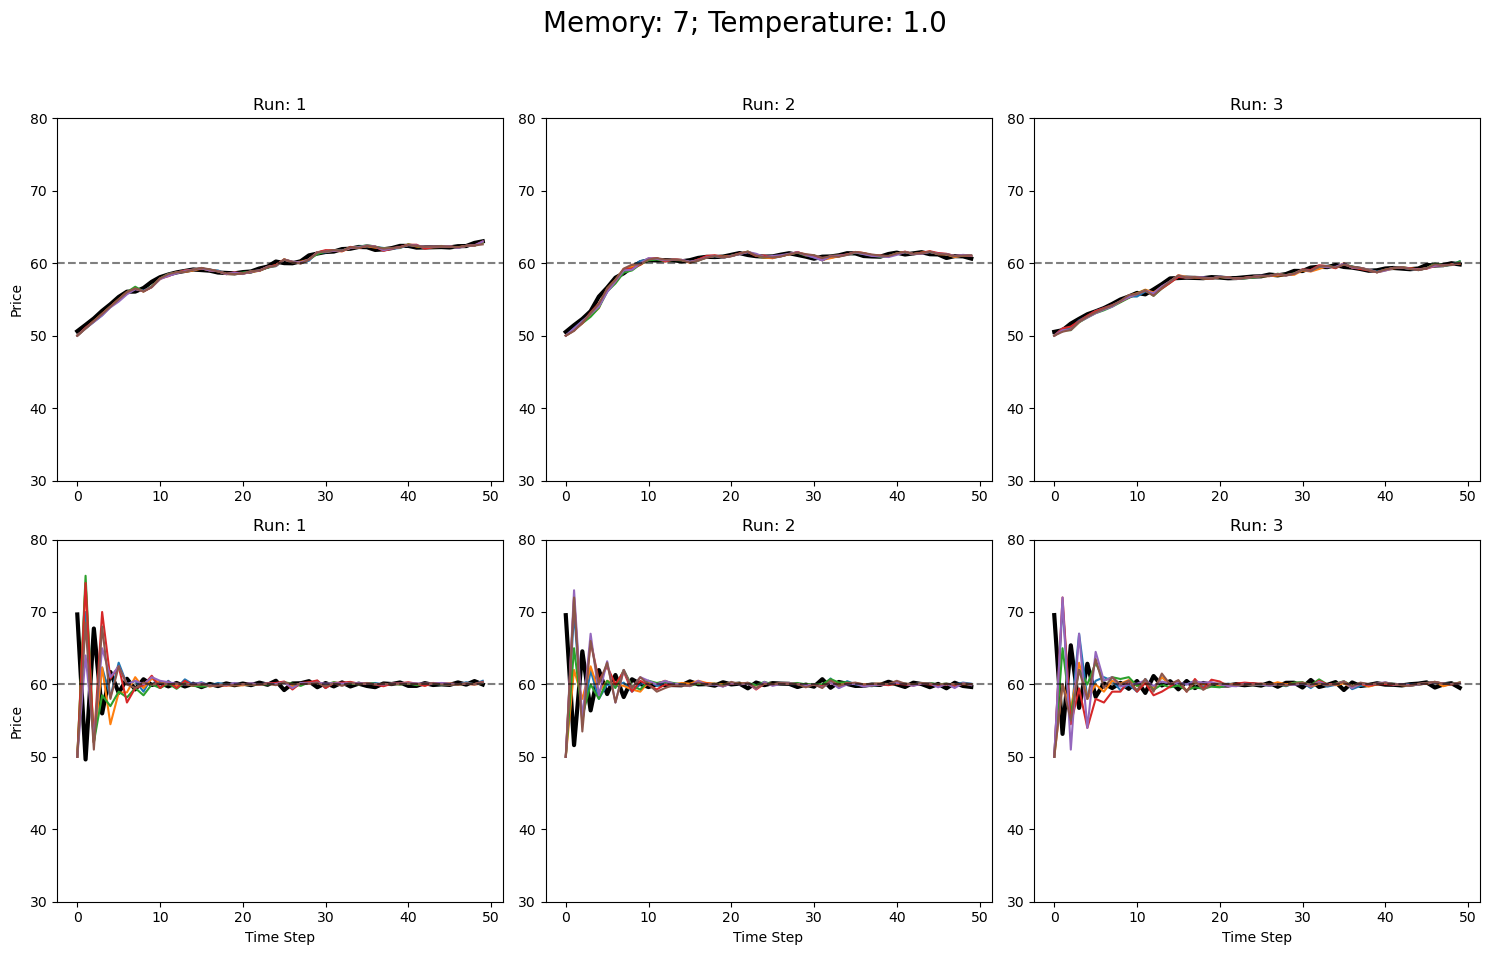

In [39]:
# Example usage
gpt_model="gpt-4-1106-preview"
memory = 7
temperature = 1.0
feedback_values = ['pos','neg']
expmnt_nums = [1, 2, 3]

plots_across_runs_and_feedback(feedback_values, expmnt_nums, gpt_model, memory, temperature)

In [ ]:
def plots_across_runs_and_feedback(feedback_values,expmnt_nums,gpt_model,memory,temperature):

    n = len(feedback_values) # number of double-rows
    m = len(expmnt_nums) # number of columns
    
    t = 0.9 # 1-t == top space 
    b = 0.1 # bottom space      (both in figure coordinates)
    
    msp = 0.1 # minor spacing
    sp = 0.5  # major spacing
    
    offs=(1+msp)*(t-b)/(2*n+n*msp+(n-1)*sp) # grid offset
    hspace_gso = (sp+msp+1) # height space per grid for gso
    hspace_gse = (sp+msp+1)*1.5 # height space per grid for gse
    
    gso = GridSpec(n,m, bottom=b+offs, top=t, hspace=hspace_gso)
    gse = GridSpec(n,m, bottom=b, top=t-offs, hspace=hspace_gse)
    
    fig = plt.figure(figsize=(10, 10))
    axes = []
    
    # Iterate over feedback_values
    k=0
    max_price_pos = 0
    min_price_pos = 100
    max_reward_pos = 0
    min_reward_pos = 100
    max_price_neg = 0
    min_price_neg = 100
    max_reward_neg = 0
    min_reward_neg = 100
    
    for i, feedback in enumerate(feedback_values):
        # Iterate over expmnt_nums
        for j, expmnt_num in enumerate(expmnt_nums):
            try:
                df = pd.read_csv("../results/experiments/expmnt_results_"+feedback+"_original_30-50w_num_"+str(expmnt_num)+\
                             "_temp_"+str(temperature).replace('.', '-')+"_memory_"+str(memory)+"_ntime_50_nagents_6.csv")
            except:
                df = pd.read_csv("../results/experiments/expmnt_results_"+feedback+"_original_30-50w_num_"+str(expmnt_num)+\
                             "_temp_"+str(temperature).replace('.', '-')+"_memory_"+str(memory)+"_ntime_50_nagents_6"+\
                                 "_model_"+str(gpt_model).replace('.', '-')+".csv")
            
            if feedback == "pos":
                max_price_pos = max(max_price_pos,max(df["predicted_price"].max(),df["actual_price"].max()))
                min_price_pos = min(min_price_pos,min(df["predicted_price"].min(),df["actual_price"].min()))
                max_reward_pos = max(max_reward_pos,df["rewards"].max())
                min_reward_pos = min(min_reward_pos,df["rewards"].min())
    
            if feedback == "neg":
                max_price_neg = max(max_price_neg,max(df["predicted_price"].max(),df["actual_price"].max()))
                min_price_neg = min(min_price_neg,min(df["predicted_price"].min(),df["actual_price"].min()))
                max_reward_neg = max(max_reward_neg,df["rewards"].max())
                min_reward_neg = min(min_reward_neg,df["rewards"].min())
    
    for i, feedback in enumerate(feedback_values):
        for j, expmnt_num in enumerate(expmnt_nums):
            try:
                df = pd.read_csv("../results/experiments/expmnt_results_"+feedback+"_original_30-50w_num_"+str(expmnt_num)+\
                             "_temp_"+str(temperature).replace('.', '-')+"_memory_"+str(memory)+"_ntime_50_nagents_6.csv")
            except:
                df = pd.read_csv("../results/experiments/expmnt_results_"+feedback+"_original_30-50w_num_"+str(expmnt_num)+\
                             "_temp_"+str(temperature).replace('.', '-')+"_memory_"+str(memory)+"_ntime_50_nagents_6"+\
                                 "_model_"+str(gpt_model).replace('.', '-')+".csv")
            
            # Plot actual and predicted prices over time_step
            ax1 = fig.add_subplot(gso[k])
            ax1.plot(df['time_step'], df['actual_price'], label='Actual Price', color="black",linewidth = 3)
            for agent_id, group in df.groupby('agent_id'):
                ax1.plot(group['time_step'], group['predicted_price'], label=f'Predicted Price (Agent {agent_id})')
            if j == 0:
                ax1.set_ylabel('Price')
            else:
                ax1.set_yticklabels([])
            ax1.set_xticklabels([])
            ax1.set_title("Run: "+str(j+1))
            ax1.axhline(60,linestyle="dashed",color="black",alpha=0.5)
            if j == 2:
                ax1.legend(bbox_to_anchor=[1.05,1])
            if i == 0:
                ax1.set_ylim(min_price_pos,max_price_pos)
            if i == 1:
                ax1.set_ylim(min_price_neg,max_price_neg)
    
                
            # Plot rewards by agent_id over time_step
            ax2 = fig.add_subplot(gse[k])
            for agent_id, group in df.groupby('agent_id'):
                ax2.plot(group['time_step'], group['rewards'], label=f'Reward (Agent {agent_id})')
    
            if j == 0:
                ax2.set_ylabel('Reward')
            else:
                ax2.set_yticklabels([])
            ax2.set_xlabel('Time Step')
            if j == 2:
                ax2.legend(bbox_to_anchor=[1.05,1])
            if i == 0:
                ax2.set_ylim(min_reward_pos,max_reward_pos)
            if i == 1:
                ax2.set_ylim(min_reward_neg,max_reward_neg)
    
            
            k += 1
    
    plt.text(0.5, 0.95, "Positive feedback", ha='center', va='center', fontsize=20, transform=fig.transFigure)
    plt.text(0.5, 0.5, "Negative feedback", ha='center', va='center', fontsize=20, transform=fig.transFigure) 
    plt.text(0.5, 1, "Memory: "+str(memory)+"; Temperature: "+str(temperature), ha='center', va='center', fontsize=20, transform=fig.transFigure)
    
    plt.tight_layout()
    
    filename = "../results/plots/"+gpt_model+"_memory_"+str(memory)+"_temperature_"+str(temperature)+".png"
    plt.savefig(filename, bbox_inches='tight')
    
    plt.show()